In [1]:
from src.modeling import load_tsla
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import matplotlib.pyplot as plt

series = load_tsla()

# This splits your data
train = series[series.index <= "2024-12-31"]

# IMPORTANT: 'order' must be defined before this line. 
# Usually you get it from auto_arima: (p, d, q)
order = (5, 1, 0)
model = ARIMA(train, order=order)
fit = model.fit()

In [2]:
n_steps = 252

forecast_res = fit.get_forecast(steps=n_steps)

forecast = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()


In [3]:
last_date = series.index[-1]

future_dates = pd.bdate_range(start=last_date, periods=n_steps+1)[1:]

forecast.index = future_dates
conf_int.index = future_dates


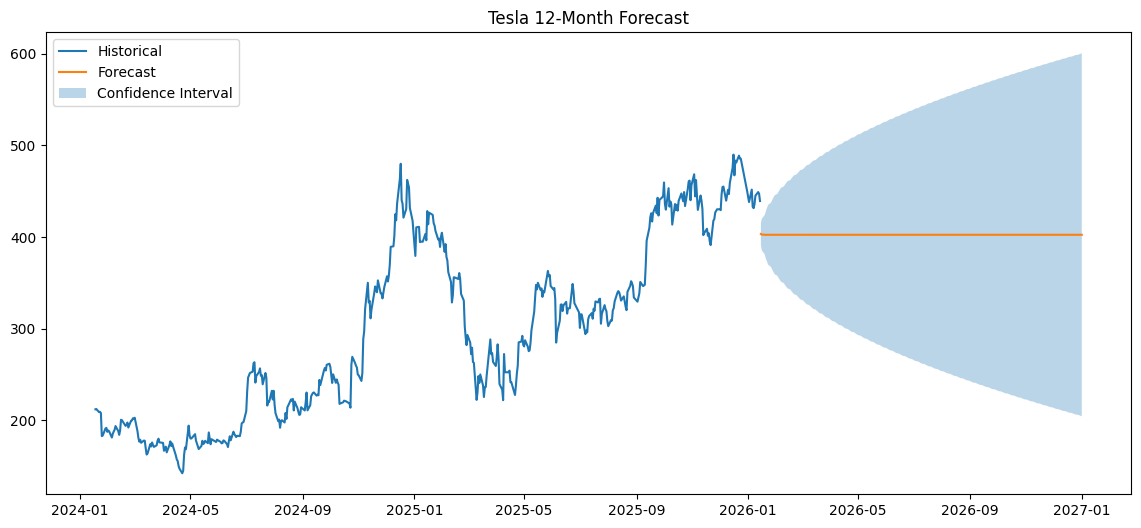

In [5]:
plt.figure(figsize=(14,6))

plt.plot(series[-500:], label="Historical")
plt.plot(forecast, label="Forecast")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("Tesla 12-Month Forecast")
plt.legend()
plt.show()

In [4]:
forecast.to_csv("data/processed/tsla_forecast_12m.csv")
conf_int.to_csv("data/processed/tsla_confidence_intervals.csv")

In [5]:
print("Last actual price:", series.iloc[-1])
print("Forecast end price:", forecast.iloc[-1])

Last actual price: 439.2000122070313
Forecast end price: 401.954151263593


In [6]:
conf_width = conf_int.iloc[:,1] - conf_int.iloc[:,0]
print(conf_width.head())
print(conf_width.tail())

2026-01-15    24.071243
2026-01-16    34.008046
2026-01-19    41.696553
2026-01-20    48.001543
2026-01-21    54.191558
Freq: B, dtype: float64
2026-12-28    390.615093
2026-12-29    391.402582
2026-12-30    392.188489
2026-12-31    392.972825
2027-01-01    393.755598
Freq: B, dtype: float64
